In [ ]:
# Cell 0 - mount google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# -------------------------
# Imports & global settings
# -------------------------
import os
import shutil
import random
from glob import glob
from tqdm import tqdm
import gc
import numpy as np
from math import ceil
import joblib

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre

# sklearn
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# plotting
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Config - adjust if needed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Paths (persist under Drive)
DATA_DRIVE_ROOT = "/content/drive/MyDrive"
# Write reorganized dataset directly to Drive so it persists across sessions:
output_path = os.path.join(DATA_DRIVE_ROOT, "BreaKHis_prepared")   # corrected location (persistent)
DATA_DIR = output_path
BASE_DIR = os.path.join(DATA_DRIVE_ROOT, "BreaKHis_project")
FEATURE_DIR = os.path.join(BASE_DIR, "features")
MODEL_DIR   = os.path.join(BASE_DIR, "models")
os.makedirs(FEATURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(BASE_DIR, exist_ok=True)

IMG_SIZE = (224, 224)   # ResNet/EfficientNet typical size; (299,299) not used since Inception is excluded
BATCH_SIZE = 16
WORKERS = 4


In [ ]:
# -------------------------
# Step 1: Reorganize dataset (copy to Drive)
# -------------------------
base_path = "/content/drive/MyDrive/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"  # original Drive location
classes = ['benign', 'malignant']
split_ratio = 0.8  # 80% train, 20% test

for cls in classes:
    print(f"Processing {cls}...")
    # adjust glob pattern if needed; this searches recursively for png/jpg/jpeg files in nested folders
    patterns = [os.path.join(base_path, cls, '**', '*.png'),
                os.path.join(base_path, cls, '**', '*.jpg'),
                os.path.join(base_path, cls, '**', '*.jpeg')]
    all_images = []
    for p in patterns:
        all_images.extend(glob(p, recursive=True))
    print(f"  Found {len(all_images)} images.")

    random.shuffle(all_images)
    split_index = int(len(all_images) * split_ratio)
    train_imgs = all_images[:split_index]
    test_imgs = all_images[split_index:]

    for subset, img_list in zip(['train', 'test'], [train_imgs, test_imgs]):
        dest_dir = os.path.join(output_path, subset, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for img_path in tqdm(img_list, desc=f"Copying {cls}/{subset}"):
            shutil.copy(img_path, dest_dir)

print("Dataset reorganized successfully at:", output_path)

Processing benign...
  Found 2480 images.


Copying benign/test: 100%|██████████| 496/496 [03:03<00:00,  2.71it/s]


Processing malignant...
  Found 5442 images.


Copying malignant/test: 100%|██████████| 1089/1089 [06:41<00:00,  2.71it/s]

Dataset reorganized successfully at: /content/drive/MyDrive/BreaKHis_prepared


In [ ]:
# -------------------------
# Step 2: Feature extraction for TWO backbones (ResNet50, EfficientNetB0)
# -------------------------
import os, gc
import numpy as np
import joblib
from tensorflow.keras import backend as K
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# CONFIG (must be defined earlier)
# DATA_DIR = "/content/data/BreaKHis_prepared"
# FEATURE_DIR = "/content/drive/MyDrive/BreaKHis_features"   # Example persistent path
# IMG_SIZE = (224, 224)
# BATCH_SIZE = 32
# WORKERS = 4   # (not used in model.predict for TF>=2.14)

os.makedirs(FEATURE_DIR, exist_ok=True)

def make_generator(preprocess_fn):
    """Create train/test image generators with preprocessing."""
    train_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
        os.path.join(DATA_DIR, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    test_gen = ImageDataGenerator(preprocessing_function=preprocess_fn).flow_from_directory(
        os.path.join(DATA_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    return train_gen, test_gen


def extract_and_save(name, ModelClass, preprocess_fn):
    """Extract deep features using pretrained CNN and save to .npy/.joblib."""
    print(f"\n=== Processing {name} ===")
    train_gen, test_gen = make_generator(preprocess_fn)

    # Initialize backbone
    K.clear_session()
    model = ModelClass(weights="imagenet", include_top=False, pooling='avg',
                       input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    train_gen.reset()
    test_gen.reset()

    # Extract features (no workers/use_multiprocessing args)
    print(f"[{name}] Predicting train features...")
    X_train = model.predict(train_gen, verbose=1)
    y_train = np.array(train_gen.classes[:len(X_train)]).astype(int)

    print(f"[{name}] Predicting test features...")
    X_test = model.predict(test_gen, verbose=1)
    y_test = np.array(test_gen.classes[:len(X_test)]).astype(int)

    # Save extracted arrays and metadata
    np.save(os.path.join(FEATURE_DIR, f"{name}_train_X.npy"), X_train)
    np.save(os.path.join(FEATURE_DIR, f"{name}_train_y.npy"), y_train)
    np.save(os.path.join(FEATURE_DIR, f"{name}_test_X.npy"), X_test)
    np.save(os.path.join(FEATURE_DIR, f"{name}_test_y.npy"), y_test)

    joblib.dump({"filenames": train_gen.filenames, "classes": train_gen.classes},
                os.path.join(FEATURE_DIR, f"{name}_train_meta.joblib"))
    joblib.dump({"filenames": test_gen.filenames, "classes": test_gen.classes},
                os.path.join(FEATURE_DIR, f"{name}_test_meta.joblib"))

    print(f"[{name}] Saved features: train {X_train.shape}, test {X_test.shape}")

    # Clean up
    del model
    K.clear_session()
    gc.collect()


# Run for 2 backbones only
extract_and_save("ResNet50", ResNet50, resnet_pre)
extract_and_save("EfficientNetB0", EfficientNetB0, effnet_pre)

# Build dictionary for downstream ML steps
features_data = {}
for name in ["ResNet50", "EfficientNetB0"]:
    Xtr = np.load(os.path.join(FEATURE_DIR, f"{name}_train_X.npy"))
    ytr = np.load(os.path.join(FEATURE_DIR, f"{name}_train_y.npy"))
    Xte = np.load(os.path.join(FEATURE_DIR, f"{name}_test_X.npy"))
    yte = np.load(os.path.join(FEATURE_DIR, f"{name}_test_y.npy"))
    features_data[name] = (Xtr, ytr, Xte, yte)



=== Processing ResNet50 ===
Found 6337 images belonging to 2 classes.
Found 1585 images belonging to 2 classes.
[ResNet50] Predicting train features...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


397/397 ━━━━━━━━━━━━━━━━━━━━ 1340s 3s/step
[ResNet50] Predicting test features...
100/100 ━━━━━━━━━━━━━━━━━━━━ 329s 3s/step
[ResNet50] Saved features: train (6337, 2048), test (1585, 2048)

=== Processing EfficientNetB0 ===
Found 6337 images belonging to 2 classes.
Found 1585 images belonging to 2 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[EfficientNetB0] Predicting train features...
397/397 ━━━━━━━━━━━━━━━━━━━━ 532s 1s/step
[EfficientNetB0] Predicting test features...
100/100 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step
[EfficientNetB0] Saved features: train (6337, 1280), test (1585, 1280)


In [ ]:
# -------------------------
# Step 3: ML training + evaluation (leakage-free CV using Pipeline)
# -------------------------
SEED = SEED
SAVE_DIR = os.path.join(BASE_DIR, "trained_models")
os.makedirs(SAVE_DIR, exist_ok=True)

def evaluate_classifiers_on_features(X_train, y_train, X_test, y_test, cv_folds=5, save_models=False):
    results = {}
    classifiers = {
        "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced', random_state=SEED),
        "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        "NaiveBayes": GaussianNB(),
        "DecisionTree": DecisionTreeClassifier(random_state=SEED, class_weight='balanced'),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1)
    }

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED)

    for name, clf in classifiers.items():
        print(f"\n==> Evaluating {name}")
        pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])

        try:
            cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
            cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
        except Exception as e:
            print(f"  CV failed for {name}: {e}")
            cv_mean, cv_std = None, None

        # Train/test scaling
        scaler = StandardScaler()
        Xtr_scaled = scaler.fit_transform(X_train)
        Xte_scaled = scaler.transform(X_test)

        # Train final model
        clf.fit(Xtr_scaled, y_train)

        # Evaluate
        y_pred = clf.predict(Xte_scaled)
        acc_test = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=['benign','malignant'])
        cm = confusion_matrix(y_test, y_pred)

        auc_val = None
        try:
            if hasattr(clf, "predict_proba"):
                y_prob = clf.predict_proba(Xte_scaled)[:, 1]
                auc_val = roc_auc_score(y_test, y_prob)
            elif hasattr(clf, "decision_function"):
                scores = clf.decision_function(Xte_scaled)
                y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
                auc_val = roc_auc_score(y_test, y_prob)
        except Exception:
            auc_val = None

        results[name] = {
            "clf": clf,
            "cv_mean": cv_mean,
            "cv_std": cv_std,
            "test_acc": acc_test,
            "test_report": report,
            "confusion": cm,
            "auc": auc_val,
            "scaler": scaler
        }

        print(f" {name}: CV acc={cv_mean} ± {cv_std} | test acc={acc_test:.4f} | AUC={auc_val}")

        # Save model/scaler if required
        if save_models:
            joblib.dump(clf, os.path.join(SAVE_DIR, f"{name}_clf.joblib"))
            joblib.dump(scaler, os.path.join(SAVE_DIR, f"{name}_scaler.joblib"))

    return results


# Run for each backbone
overall_summary = {}
for backbone_name, (Xtr, ytr, Xte, yte) in features_data.items():
    print("\n" + "="*50)
    print("Backbone:", backbone_name)
    res = evaluate_classifiers_on_features(Xtr, ytr, Xte, yte, cv_folds=5, save_models=True)
    overall_summary[backbone_name] = res

# Summarize results
import pandas as pd
rows = []
for bname, res in overall_summary.items():
    for mname, info in res.items():
        rows.append((bname, mname, info["cv_mean"], info["cv_std"], info["test_acc"], info["auc"]))
df_summary = pd.DataFrame(rows, columns=["Backbone","Model","CV_mean","CV_std","Test_acc","AUC"])
display(df_summary.sort_values(["Backbone","Test_acc"], ascending=[True, False]))



Backbone: ResNet50

==> Evaluating SVM
 SVM: CV acc=0.935615191751797 ± 0.010017456764142946 | test acc=0.9356 | AUC=0.9832748304155928

==> Evaluating KNN
 KNN: CV acc=0.891116525038654 ± 0.0057399288768586795 | test acc=0.9091 | AUC=0.9590063020231642

==> Evaluating NaiveBayes
 NaiveBayes: CV acc=0.8292563720156657 ± 0.005141557849571359 | test acc=0.7981 | AUC=0.7896005509641874

==> Evaluating DecisionTree
 DecisionTree: CV acc=0.8204240624042984 ± 0.01567331223295451 | test acc=0.8202 | AUC=0.7922961284398234

==> Evaluating RandomForest
 RandomForest: CV acc=0.8769142189876978 ± 0.005423867969767867 | test acc=0.8675 | AUC=0.9539317293166267

Backbone: EfficientNetB0

==> Evaluating SVM
 SVM: CV acc=0.9324577543515445 ± 0.007194827439995483 | test acc=0.9319 | AUC=0.9747252584495987

==> Evaluating KNN
 KNN: CV acc=0.8914304885730718 ± 0.008414065603610998 | test acc=0.8965 | AUC=0.9461856467904854

==> Evaluating NaiveBayes
 NaiveBayes: CV acc=0.7972207629239193 ± 0.0069339685

,Backbone,Model,CV_mean,CV_std,Test_acc,AUC
5,EfficientNetB0,SVM,0.932458,0.007195,0.931861,0.974725
6,EfficientNetB0,KNN,0.891430,0.008414,0.896530,0.946186
9,EfficientNetB0,RandomForest,0.855295,0.006646,0.852997,0.940445
7,EfficientNetB0,NaiveBayes,0.797221,0.006934,0.788013,0.820142
8,EfficientNetB0,DecisionTree,0.768504,0.010263,0.771609,0.731143
0,ResNet50,SVM,0.935615,0.010017,0.935647,0.983275
1,ResNet50,KNN,0.891117,0.005740,0.909148,0.959006
4,ResNet50,RandomForest,0.876914,0.005424,0.867508,0.953932
3,ResNet50,DecisionTree,0.820424,0.015673,0.820189,0.792296
2,ResNet50,NaiveBayes,0.829256,0.005142,0.798107,0.789601


In [ ]:
# -------------------------
# Step 4: Select best per backbone and overall, plot, compute ROC, CM, metrics
# -------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, precision_score, recall_score, f1_score, mean_squared_error

# find best model per backbone
best_per_backbone = {}
for bname, res in overall_summary.items():
    best_name, best_acc = None, -1
    for mname, info in res.items():
        if info['test_acc'] is not None and info['test_acc'] > best_acc:
            best_acc = info['test_acc']
            best_name = mname
    best_per_backbone[bname] = (best_name, res[best_name])

# bar chart for best per backbone
labels, values = [], []
for bname, (mname, info) in best_per_backbone.items():
    labels.append(f"{bname}\n{mname}")
    values.append(info["test_acc"] if info["test_acc"] is not None else 0.0)

plt.figure(figsize=(8,4))
bars = plt.bar(labels, values, color='skyblue', edgecolor='black')
plt.ylim(0,1)
plt.title("Best model (per backbone) - Test Accuracy")
plt.ylabel("Test accuracy")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha='center')
plt.tight_layout()
plt.show()

# find overall best model
overall_best = None
best_val = -1
for bname, (mname, info) in best_per_backbone.items():
    if info['test_acc'] is not None and info['test_acc'] > best_val:
        best_val = info['test_acc']
        overall_best = (bname, mname, info)

print(f"\nOverall best: {overall_best[0]} - {overall_best[1]} | Test accuracy: {best_val:.4f}")

# extract info for metrics and plots
bname, mname, info = overall_best
clf = info['clf']
scaler = info['scaler']
Xtr, ytr, Xte, yte = features_data[bname]
Xte_scaled = scaler.transform(Xte)

# predictions and probabilities
y_pred = clf.predict(Xte_scaled)
y_prob = None
if hasattr(clf, "predict_proba"):
    y_prob = clf.predict_proba(Xte_scaled)[:, 1]
elif hasattr(clf, "decision_function"):
    s = clf.decision_function(Xte_scaled)
    y_prob = (s - s.min()) / (s.max() - s.min() + 1e-9)

# --- Confusion Matrix ---
cm = confusion_matrix(yte, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {bname}_{mname}')
plt.show()

# --- Additional Performance Metrics ---
precision = precision_score(yte, y_pred)
recall = recall_score(yte, y_pred)
f1 = f1_score(yte, y_pred)
mse = mean_squared_error(yte, y_pred)

print("\nPerformance Metrics:")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"MSE:       {mse:.6f}")

# --- ROC Curve ---
if y_prob is not None:
    fpr, tpr, _ = roc_curve(yte, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {bname}_{mname}")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No probability scores available; skipping ROC curve.")


In [ ]:
# -------------------------
# Step 5: Save overall best model + scaler
# -------------------------
os.makedirs(MODEL_DIR, exist_ok=True)
bname, mname, info = overall_best
clf = info.get('clf')
scaler = info.get('scaler') #normalised data

if clf is None or scaler is None:
    print("Model or scaler not found. Make sure evaluation completed successfully.")
else:
    model_fname = os.path.join(MODEL_DIR, f"{bname}_{mname}_best.joblib")
    scaler_fname = os.path.join(MODEL_DIR, f"{bname}_{mname}_scaler.joblib")
    joblib.dump(clf, model_fname)
    joblib.dump(scaler, scaler_fname)
    print("Saved model to:", model_fname)
    print("Saved scaler to:", scaler_fname)

In [ ]:
# -------------------------
# Step 6: Example single-image prediction using saved classifier + backbone
# -------------------------
import cv2
import os
import numpy as np
from tensorflow.keras.applications import ResNet50, EfficientNetB0

# (Assuming MODEL_DIR, bname, mname, IMG_SIZE, resnet_pre, and effnet_pre are already defined)

model_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_best.joblib")
scaler_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_scaler.joblib")
clf = joblib.load(model_path)
scaler = joblib.load(scaler_path)
print("Loaded classifier and scaler.")

# Select backbone
if bname == "ResNet50":
    backbone = ResNet50(weights="imagenet", include_top=False, pooling='avg', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    preprocess_fn = resnet_pre
elif bname == "EfficientNetB0":
    backbone = EfficientNetB0(weights="imagenet", include_top=False, pooling='avg', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    preprocess_fn = effnet_pre
else:
    raise ValueError("Unexpected backbone selection.")

def predict_single_image(img_path, backbone, clf, scaler, preprocess_fn, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    x = np.expand_dims(img.astype('float32'), axis=0)
    x = preprocess_fn(x)
    feats = backbone.predict(x, verbose=0)
    feats_scaled = scaler.transform(feats)
    pred = clf.predict(feats_scaled)[0]
    label = "malignant" if int(pred) == 1 else "benign"
    print(f"Predicted class: {label}")
    return label

# Example prediction using your image
predict_single_image(
    "/content/drive/MyDrive/BreaKHis_prepared/test/benign/SOB_B_A-14-22549AB-100-004.png",
    backbone,
    clf,
    scaler,
    preprocess_fn
)
#malignant: /content/drive/MyDrive/BreaKHis_prepared/test/malignant/SOB_M_DC-14-11951-40-027.png
#benign: /content/drive/MyDrive/BreaKHis_prepared/test/benign/SOB_B_A-14-22549CD-400-013.png

In [ ]:
#only when re-opening
from google.colab import drive
drive.mount('/content/drive')

import joblib
import os

# Paths to your saved models and scalers (adjust if needed)
MODEL_DIR = "/content/drive/MyDrive/trained_models"
FEATURE_DIR = "/content/drive/MyDrive/features"


# Example: load best saved model and scaler
model_path = os.path.join(MODEL_DIR, "ResNet50_SVM_clf.joblib")
scaler_path = os.path.join(MODEL_DIR, "ResNet50_SVM_scaler.joblib")

clf = joblib.load(model_path)
scaler = joblib.load(scaler_path)

print("Model and scaler loaded successfully.")


In [ ]:
# -------------------------
# Step 6: Example single-image prediction using saved classifier + backbone
# -------------------------

import os
import cv2
import numpy as np
import joblib
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre

# -------------------------
# Define required constants
# -------------------------

MODEL_DIR = "/content/drive/MyDrive/BreaKHis_project/models"   # Folder where your model is saved
bname = "ResNet50"                                             # Backbone name
mname = "SVM"                                                  # Classifier name
IMG_SIZE = (224, 224)                                          # Image size for model input

# -------------------------
# Load model and scaler
# -------------------------
model_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_best.joblib")
scaler_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_scaler.joblib")

clf = joblib.load(model_path)
scaler = joblib.load(scaler_path)

print("Loaded classifier and scaler successfully.")

# -------------------------
# Select backbone
# -------------------------
if bname == "ResNet50":
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        pooling='avg',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    preprocess_fn = resnet_pre

elif bname == "EfficientNetB0":
    backbone = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling='avg',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    preprocess_fn = effnet_pre

else:
    raise ValueError("Unexpected backbone selection.")

# -------------------------
# Define prediction function
# -------------------------
def predict_single_image(img_path, backbone, clf, scaler, preprocess_fn, img_size=IMG_SIZE):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, img_size)
    x = np.expand_dims(img.astype('float32'), axis=0)
    x = preprocess_fn(x)

    feats = backbone.predict(x, verbose=0)
    feats_scaled = scaler.transform(feats)

    pred = clf.predict(feats_scaled)[0]
    label = "malignant" if int(pred) == 1 else "benign"
    print(f"Predicted class: {label}")
    return label

# -------------------------
# Example prediction (replace path as needed)
# -------------------------
test_image_path = "/content/drive/MyDrive/BreaKHis_prepared/test/benign/SOB_B_A-14-22549AB-200-016.png"
predict_single_image(test_image_path, backbone, clf, scaler, preprocess_fn)


Loaded classifier and scaler successfully.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Predicted class: benign


'benign'

Loaded classifier and scaler successfully.


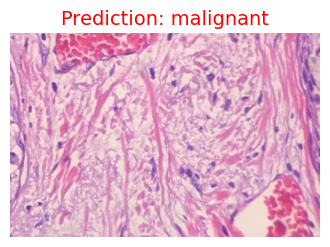

Predicted class: malignant


'malignant'

In [ ]:
# -------------------------
# Step 6: Example single-image prediction using saved classifier + backbone
# -------------------------

import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet import preprocess_input as resnet_pre
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_pre

# -------------------------
# Define required constants
# -------------------------

MODEL_DIR = "/content/drive/MyDrive/BreaKHis_project/models"   # Folder where your model is saved
bname = "ResNet50"                                             # Backbone name
mname = "SVM"                                                  # Classifier name
IMG_SIZE = (224, 224)                                          # Image size for model input

# -------------------------
# Load model and scaler
# -------------------------
model_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_best.joblib")
scaler_path = os.path.join(MODEL_DIR, f"{bname}_{mname}_scaler.joblib")

clf = joblib.load(model_path)
scaler = joblib.load(scaler_path)

print("Loaded classifier and scaler successfully.")

# -------------------------
# Select backbone
# -------------------------
if bname == "ResNet50":
    backbone = ResNet50(
        weights="imagenet",
        include_top=False,
        pooling='avg',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    preprocess_fn = resnet_pre

elif bname == "EfficientNetB0":
    backbone = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling='avg',
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
    )
    preprocess_fn = effnet_pre

else:
    raise ValueError("Unexpected backbone selection.")

# -------------------------
# Define prediction function (with image display)
# -------------------------
def predict_single_image(img_path, backbone, clf, scaler, preprocess_fn, img_size=IMG_SIZE):
    # Load image
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, img_size)

    # Preprocess
    x = np.expand_dims(img_resized.astype('float32'), axis=0)
    x = preprocess_fn(x)

    # Extract features and predict
    feats = backbone.predict(x, verbose=0)
    feats_scaled = scaler.transform(feats)
    pred = clf.predict(feats_scaled)[0]
    label = "malignant" if int(pred) == 1 else "benign"

    # Display image with label
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}", fontsize=14, color='red' if label == 'malignant' else 'green')
    plt.axis('off')
    plt.show()

    print(f"Predicted class: {label}")
    return label

# -------------------------
# Example prediction (replace path as needed)
# -------------------------
test_image_path = "/content/drive/MyDrive/BreaKHis_prepared/test/malignant/SOB_M_DC-14-11031-200-010.png"
predict_single_image(test_image_path, backbone, clf, scaler, preprocess_fn)
